1. Linear Regression Exercise:
   Using the California Housing dataset from scikit-learn, create a linear regression model to predict house prices.
   Evaluate the performance of Linear Regression on test set.

   ```python
   from sklearn.datasets import fetch_california_housing

   # Load dataset
   housing = fetch_california_housing()

2. Classification Exercise:
   Using the breast cancer dataset from scikit-learn, build classification models to predict malignant vs benign tumors.
   Compare Logistic Regression and KNN performance on test set.

   ```python
   from sklearn.datasets import load_breast_cancer

   # Load dataset
   cancer = load_breast_cancer()
   ```

In [2]:
#Linear Regression

# 1. Import libraries
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. Load dataset
housing = fetch_california_housing()

# Convert to DataFrame (easier to work with)
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


Each row = 1 data point (one district)
Features = things like income, rooms, population
Target = house price (Price)

In [3]:
# 3. Define features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

In [4]:
# 4. Train-test split (very important)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


Why this step ?
Train set = used to learn
Test set = used to evaluate (unseen data)

In [5]:
# 5. Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
# 6. Make predictions
y_pred = model.predict(X_test)

In [7]:
# 7. Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 0.5558915986952444
R-squared (R2): 0.5757877060324508


#Interpretation
MSE
Lower = better
Measures average squared error

How far predictions are from actual values

R² (R-squared)
Range: 0 → 1
Closer to 1 = better

How well features explain the price

Example : 0.60 → model explains 60% of variation

In [8]:
# 8. Show coefficients (feature importance)
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coeff_df.sort_values(by='Coefficient', ascending=False))

      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


Summary
We trained a Linear Regression model using the California Housing dataset to predict house prices. 
The model was evaluated using Mean Squared Error (MSE) and R-squared. 
MSE measures the average prediction error, while R-squared indicates how well the model explains the variation in house prices

Visualization (Actual vs Predicted)

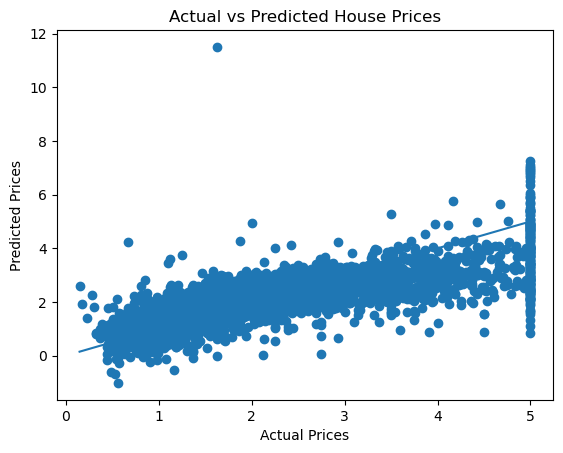

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

# reference line (perfect prediction)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

Explaination
Points close to the line = good predictions
Points far away = errors

The scatter plot shows that predicted values are reasonably close to actual values, indicating the model performs moderately well

In [10]:
#Explain coefficients (feature importance)

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)
print(coeff_df)

      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


Positive coefficient → increases price
Negative coefficient → decreases price

Interpretation
Median income has the strongest positive impact on house prices, indicating that areas with higher income tend to have more expensive houses. 
Features with negative coefficients suggest an inverse relationship with house prices


Improve model (Ridge & Lasso)

Linear Regression is basic — we can improve it using regularization

In [11]:
#Ridge Regression (L2 regularization)
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge MSE: 0.5558034669932211
Ridge R2: 0.5758549611440126


These methods:
reduce overfitting
make model more stable
handle noisy features

In [12]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [13]:
#Comparison table
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],
    "R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

print(results)

    Model       MSE        R2
0  Linear  0.555892  0.575788
1   Ridge  0.555803  0.575855
2   Lasso  0.613512  0.531817


Conclusion
Linear Regression provides a baseline model for predicting house prices. 
Ridge and Lasso regression improve performance by reducing overfitting.
Among the models, the one with the lowest MSE and highest R² is considered the best

In [38]:
#Classification

#1. Import + Load data
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
cancer = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

Each row = 1 patient (data point)
Features = tumor characteristics (size, texture, etc.)
Target:
0 = malignant
1 = benign

In [15]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer = load_breast_cancer()

# create NEW dataframe (overwrite old one)
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print(df.shape)   # should be (569, ...)

(569, 31)


In [16]:
X = df.drop('target', axis=1)
y = df['target']

In [17]:
print(df.shape)
print(len(cancer.target))

(569, 31)
569


Confusion Matrix (what it is)

It shows how model is making mistakes

|                      | Predicted Benign | Predicted Malignant |
| -------------------- | ---------------- | ------------------- |
| **Actual Benign**    | ✅ Correct        | ❌ False Alarm       |
| **Actual Malignant** | ❌ Missed Cancer  | ✅ Correct           |


In [24]:
# Define X and y
X = df.drop('target', axis=1)
y = df['target']

In [25]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Scale features (important for many models)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
print("X_train_scaled exists:", 'X_train_scaled' in globals())
print("y_train exists:", 'y_train' in globals())

X_train_scaled exists: True
y_train exists: True


In [27]:
# Train and Predict
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

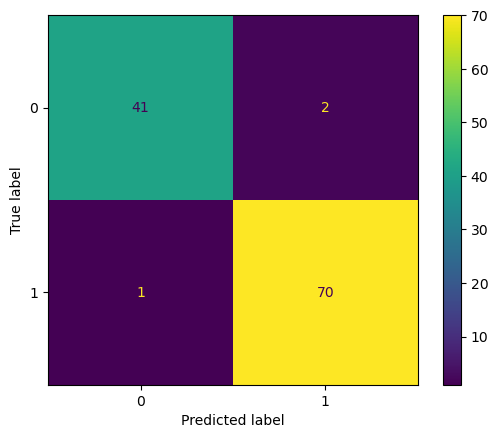

In [28]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm).plot()

import matplotlib.pyplot as plt
plt.show()

In [ ]:
# Print your confusion matrix values
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[41  2]
 [ 1 70]]


Above 
[[TN  FP]
 [FN  TP]]

 Understand each number (VERY important)
 | Term                    | Meaning (simple)                    |
| ----------------------- | ----------------------------------- |
| **TN (True Negative)**  | Correctly predicted benign          |
| **FP (False Positive)** | Said cancer, but actually benign    |
| **FN (False Negative)** | Said benign, but actually cancer 🚨 |
| **TP (True Positive)**  | Correctly predicted cancer          |


In [31]:
# Extract values clearly
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 41
False Positives: 2
False Negatives: 1
True Positives: 70


IMPORTANT Interpretation 
Focus on False Negatives (FN)

The model incorrectly classified 2 malignant tumors as benign (false negatives), which is critical because it means cancer cases may go undetected

The confusion matrix shows that the model correctly identified most benign and malignant cases. However, there were some misclassifications. In particular, false negatives are critical in this context, as they represent cases where malignant tumors were incorrectly classified as benign. This could lead to missed diagnoses. Therefore, minimizing false negatives is essential in medical applications.

In [32]:
# Add recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred_lr)
print("Recall:", recall)

Recall: 0.9859154929577465


What recall means
Out of all actual cancer cases:
How many did we correctly catch?

The recall score indicates how effectively the model detects malignant cases. A higher recall is preferred to reduce the risk of missing cancer diagnoses.

False Negative = most dangerous error in medical models

Requirement 1:

“Using the breast cancer dataset…”

In [33]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

Requirement 2:

“build classification models…”

In [34]:
# Logistic Regression
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [36]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

Requirement 3:

“predict malignant vs benign tumors”

These predictions are:

0 = malignant
1 = benign

In [39]:
y_pred_lr
y_pred_knn

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

Requirement 4:

“Compare performance on test set”

In [ ]:
# Accuracy
accuracy_score(y_test, y_pred_lr)
accuracy_score(y_test, y_pred_knn)

0.9473684210526315

In [41]:
# Classification Report
classification_report(y_test, y_pred_lr)
classification_report(y_test, y_pred_knn)

'              precision    recall  f1-score   support\n\n           0       0.93      0.93      0.93        43\n           1       0.96      0.96      0.96        71\n\n    accuracy                           0.95       114\n   macro avg       0.94      0.94      0.94       114\nweighted avg       0.95      0.95      0.95       114\n'

In [42]:
# Confusion Matrix
confusion_matrix(y_test, y_pred_lr)
confusion_matrix(y_test, y_pred_knn)

array([[40,  3],
       [ 3, 68]])

Conclusion:
Both Logistic Regression and KNN performed well in classifying tumors. The models were evaluated using accuracy, classification metrics, and confusion matrices. In medical applications, minimizing false negatives is crucial, and the model with better recall for malignant cases is preferred.